# Polarisation orientation compensation

- Open the San Francisco ALOS-1 scattering matrix.
- Convert `S` to `T3`.
- Apply 4 × 1 multilooking to reduce the number of azimuth lines.
- Estimate and compensate the polarimetric orientation.
- Display the orientation angle and corrected Pauli RGB image.

In [1]:
from pathlib import Path

import dask
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar

from polsarpro.io import open_netcdf_beam
from polsarpro.polarisation import orientation_compensation
from polsarpro.util import S_to_T3, multilook, pauli_rgb

input_file = Path("/data/psp/test_files/SAN_FRANCISCO_ALOS1_slc.nc")

In [2]:
S = open_netcdf_beam(input_file)
print(S)

<xarray.Dataset> Size: 736MB
Dimensions:  (y: 18432, x: 1248)
Coordinates:
  * y        (y) int64 147kB 0 1 2 3 4 5 ... 18426 18427 18428 18429 18430 18431
  * x        (x) int64 10kB 0 1 2 3 4 5 6 ... 1241 1242 1243 1244 1245 1246 1247
Data variables:
    hh       (y, x) complex64 184MB dask.array<chunksize=(624, 576), meta=np.ndarray>
    hv       (y, x) complex64 184MB dask.array<chunksize=(624, 576), meta=np.ndarray>
    vh       (y, x) complex64 184MB dask.array<chunksize=(624, 576), meta=np.ndarray>
    vv       (y, x) complex64 184MB dask.array<chunksize=(624, 576), meta=np.ndarray>
Attributes:
    poltype:      S
    description:  Scattering matrix


## Prepare the coherency matrix

Four azimuth looks reduce the number of image lines before orientation estimation and correction.

In [3]:
T3 = S_to_T3(S)
T3 = multilook(T3, dim_az=4, dim_rg=1)
print(T3)

<xarray.Dataset> Size: 207MB
Dimensions:  (y: 4608, x: 1248)
Coordinates:
  * y        (y) float64 37kB 1.5 5.5 9.5 13.5 ... 1.842e+04 1.843e+04 1.843e+04
  * x        (x) float64 10kB 0.0 1.0 2.0 3.0 ... 1.245e+03 1.246e+03 1.247e+03
Data variables:
    m11      (y, x) float32 23MB dask.array<chunksize=(156, 576), meta=np.ndarray>
    m22      (y, x) float32 23MB dask.array<chunksize=(156, 576), meta=np.ndarray>
    m33      (y, x) float32 23MB dask.array<chunksize=(156, 576), meta=np.ndarray>
    m12      (y, x) complex64 46MB dask.array<chunksize=(156, 576), meta=np.ndarray>
    m13      (y, x) complex64 46MB dask.array<chunksize=(156, 576), meta=np.ndarray>
    m23      (y, x) complex64 46MB dask.array<chunksize=(156, 576), meta=np.ndarray>
Attributes:
    poltype:      T3
    description:  Coherency matrix (3x3)


## Estimate and compensate the orientation

The function returns the corrected T3 matrix and the angle estimated with a 3 × 3 spatial window.

In [4]:
corrected_lazy, orientation_lazy = orientation_compensation(
    T3, boxcar_size=(3, 3)
)
pauli_lazy = pauli_rgb(corrected_lazy)

with ProgressBar():
    corrected, orientation, pauli = dask.compute(
        corrected_lazy, orientation_lazy, pauli_lazy
    )

[########################################] | 100% Completed | 13.19 s


## Display the result

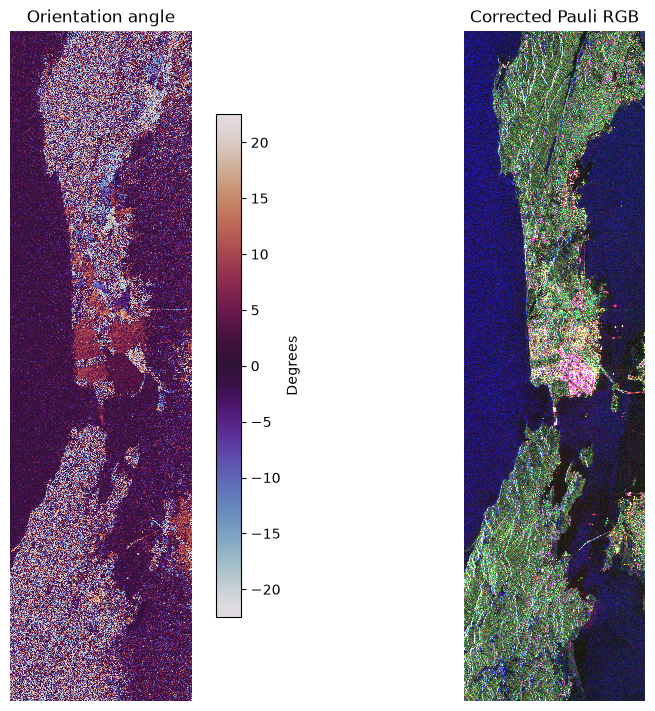

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(11, 7), constrained_layout=True)
angle = axes[0].imshow(
    orientation.orientation_angle,
    cmap="twilight",
    vmin=-22.5,
    vmax=22.5,
    interpolation="none",
)
axes[0].set_title("Orientation angle")
figure.colorbar(angle, ax=axes[0], label="Degrees", shrink=0.75)
axes[1].imshow(
    pauli.transpose("y", "x", "band"), interpolation="none"
)
axes[1].set_title("Corrected Pauli RGB")
for axis in axes:
    axis.axis("off")
plt.show()